In [1]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [2]:
# Make sure that the working directory is the project root.
%cd -q ../

In [3]:
import torch
import pickle
import numpy as np
from autoregltl import ted, llama, mamba, dataset
from autoregltl.ltl import trace_check

from tqdm.auto import tqdm
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 192
mpl.rcParams['svg.fonttype'] = 'none'  # Critical: don't convert text to paths
plt.rcParams['pdf.use14corefonts'] = True

device = torch.device('cuda')

In [4]:
redgreen = mpl.colors.LinearSegmentedColormap(
    "redgreen",
    {
        'red': (
            (0.0, 1.0, 1.0),
            (0.15873*3, 1.0, 1.0),
            (0.174603*3, 0.96875, 0.96875),
            (1.0, 0.0, 0.0),
        ),
        'green': (
            (0.0, 0.0, 0.0),
            (0.15873*3, 0.9375, 0.9375),
            (0.174603*3, 1.0, 1.0),
            (1.0, 1.0, 1.0),
        ),
        'blue': (
            (0.0, 0.0, 0.0),
            (1.0, 0.0, 0.0),
        ),
    }
)

In [5]:
def read_eval2da(filename):
    with open(filename, 'rb') as f: evaldict = pickle.load(f)
    #torch.load(filename, map_location=torch.device('cpu'))
    # dict_keys(['correct_matrix', 'count_matrix', 'correct', 'count', 'repeat_count', 'eval_ds', 'all_results'])
        
    count_matrix = evaldict['count_matrix']
    correct_matrix = evaldict['correct_matrix']
    sample_rate = count_matrix / 10.0
    eval_results = torch.where(count_matrix > 0, correct_matrix / count_matrix, 0.0)

    return eval_results, sample_rate, evaldict['correct'], evaldict['count']

# GPT

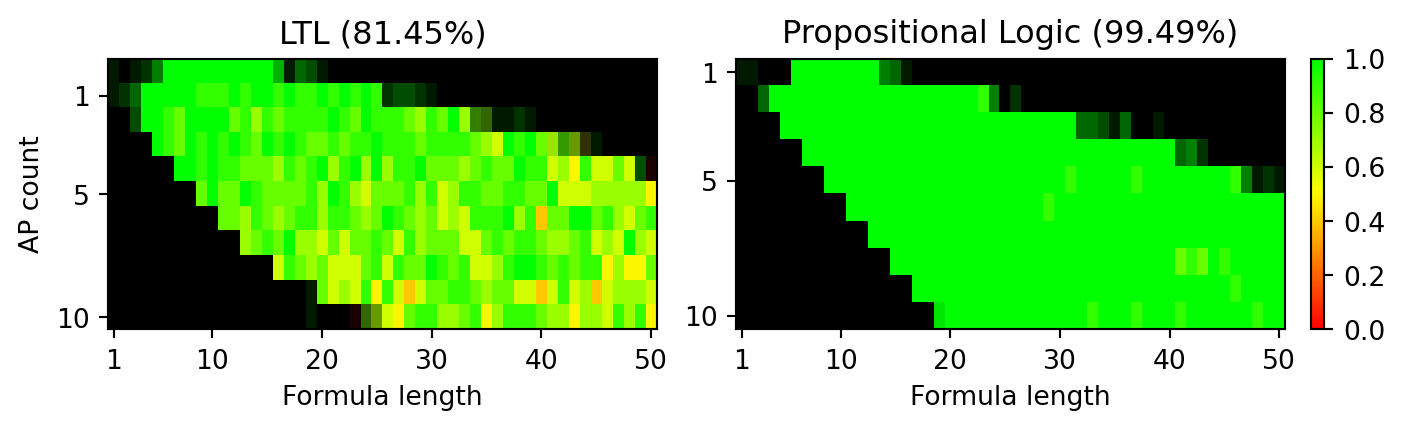

In [13]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
# 7.2 =~ 12 * ((2304 - 232) * .5 + 232+96) / 2304
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7.2, 2.125),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs[0]
eval_results, sample_rate, correct, count = read_eval2da("openai-results/gpt-5.2/medium/low/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
# Plotting the modulus array as the 'value' part
black = torch.zeros(10+1, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
ax.set_title(f"LTL ({100.0*correct/count:.2f}%)")

full_count = count

ax = axs[1]
eval_results, sample_rate, correct, count = read_eval2da("openai-results/prop/gpt-5.2/medium/low/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
black = torch.zeros(10, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks([i-1 for i in yticks], yticks)
ax.set_title(f"Propositional Logic ({100.0*correct/count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("gpt52.png", dpi=300, bbox_inches='tight')

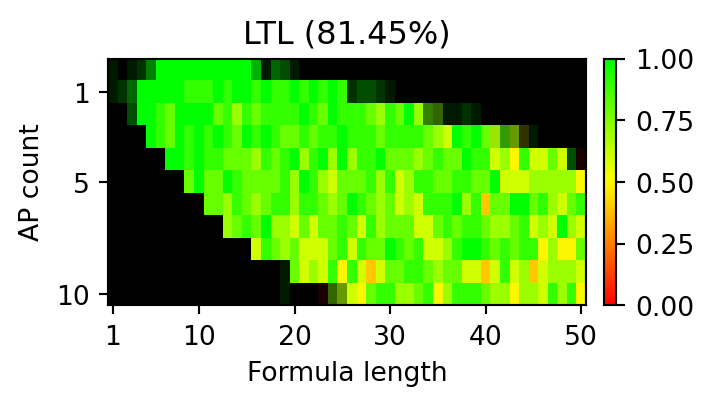

In [7]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
# 7.2 =~ 12 * ((2304 - 232) * .5 + 232+96) / 2304
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(3.6, 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs
eval_results, sample_rate, correct, count = read_eval2da("openai-results/gpt-5.2/medium/low/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
# Plotting the modulus array as the 'value' part
black = torch.zeros(10+1, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
ax.set_title(f"LTL ({100.0*correct/count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("gpt52-ltl.pdf", dpi=300, bbox_inches='tight')

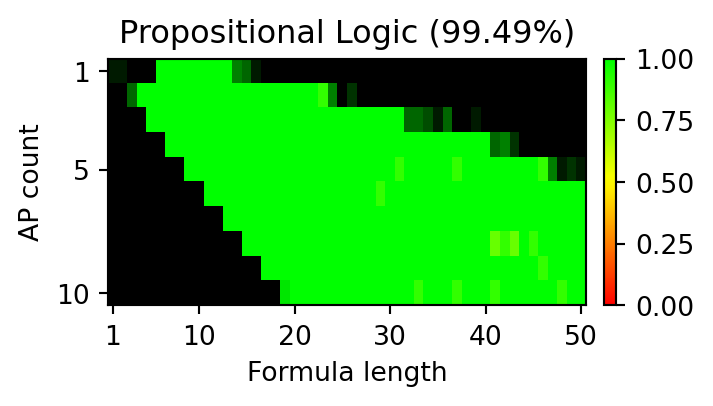

In [8]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
# 7.2 =~ 12 * ((2304 - 232) * .5 + 232+96) / 2304
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(3.6, 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs
eval_results, sample_rate, correct, count = read_eval2da("openai-results/prop/gpt-5.2/medium/low/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
black = torch.zeros(10, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks([i-1 for i in yticks], yticks)
ax.set_title(f"Propositional Logic ({100.0*correct/count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("gpt52-prop.pdf", dpi=300, bbox_inches='tight')